# Figure 3 — Forest plot of realistic rule gain (Employee Attrition, B&W)

Each rule's bootstrap 95\% CI for the realistic rule gain (USD per matched transaction; see Methodology §3 *Units and aggregation*). Rules with the entire CI above the break-even threshold ($G=0$) are *Accepted* (open circle); rules entirely below are *Rejected* (filled triangle); straddlers (if any) are *Uncertain* (gray square).

This figure illustrates the article's central empirical claim: ~42\% of statistically significant rules are economically rejected.

**Output:** `article/figures/fig3_forest_attrition.pdf`.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import pandas as pd
REPO = Path.cwd()
while not (REPO / 'pyproject.toml').exists() and REPO != REPO.parent:
    REPO = REPO.parent
if str(REPO / 'notebooks' / 'article' / 'figures') not in sys.path:
    sys.path.insert(0, str(REPO / 'notebooks' / 'article' / 'figures'))
from _style import DOUBLE_COL_INCHES, CATEGORY_STYLE, apply_rc
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
apply_rc()
CSV = REPO / 'article' / 'results' / 'rule_level_cis.csv'
PDF = REPO / 'article' / 'figures' / 'fig3_forest_attrition.pdf'
df = pd.read_csv(CSV)
df = df[(df['dataset'] == 'IBM Employee Attrition') & (df['method'] == 'bootstrap_percentile')].copy()
df = df.sort_values('gain_point').reset_index(drop=True)
def _cat(row):
    if row['gain_ci_lower'] >= 0:
        return 'accept'
    if row['gain_ci_upper'] < 0:
        return 'reject'
    return 'uncertain'
df['category'] = df.apply(_cat, axis=1)
print(df['category'].value_counts().to_dict())

{'accept': 12, 'reject': 8, 'uncertain': 1}


wrote article\figures\fig3_forest_attrition.pdf


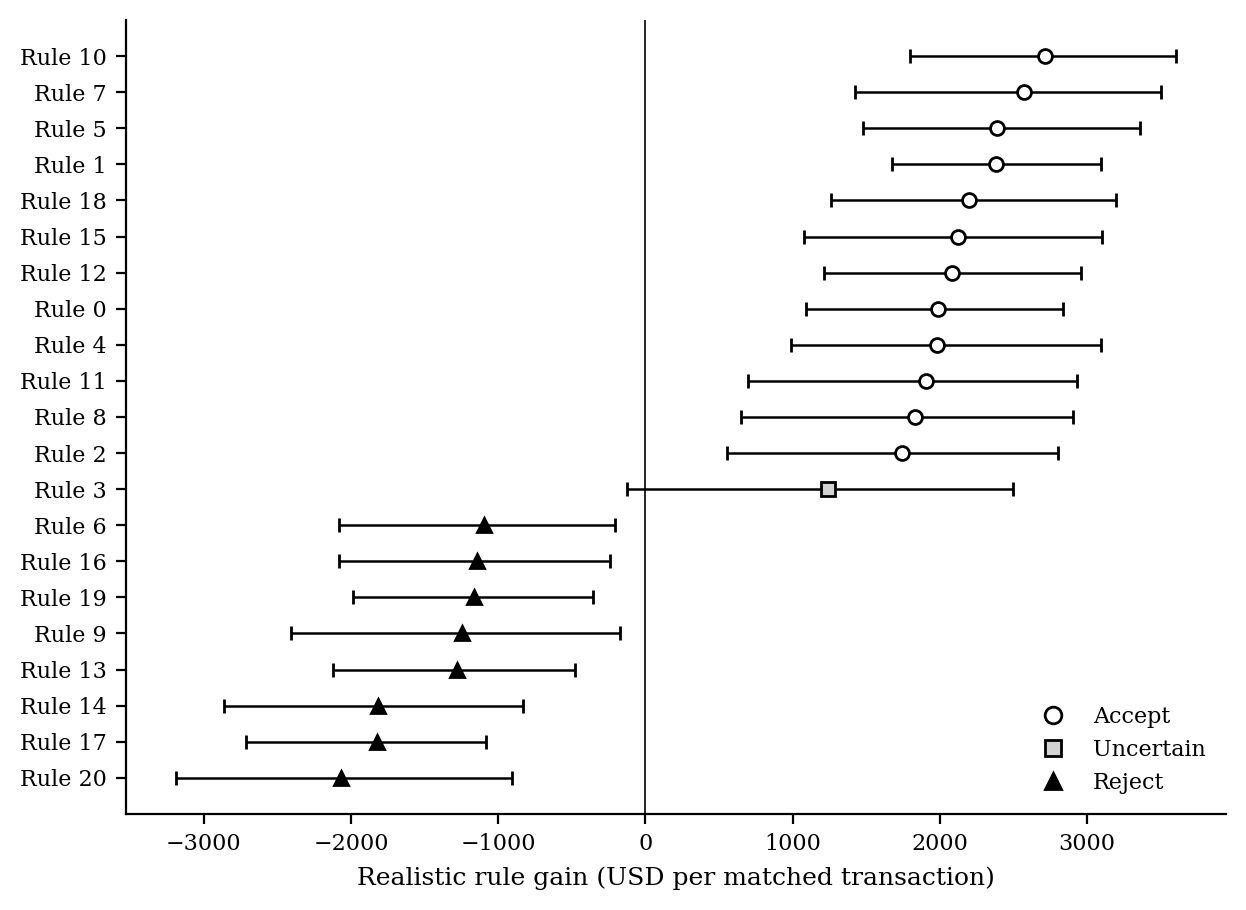

In [2]:
fig, ax = plt.subplots(figsize=(DOUBLE_COL_INCHES * 0.9, max(1.8, len(df) * 0.22)))
for i, row in df.iterrows():
    style = CATEGORY_STYLE[row['category']]
    ax.errorbar(
        row['gain_point'], i,
        xerr=[[max(row['gain_point'] - row['gain_ci_lower'], 0)],
              [max(row['gain_ci_upper'] - row['gain_point'], 0)]],
        fmt=style['marker'], color='black', ecolor='black', capsize=2.5,
        markerfacecolor=style['face'], markeredgecolor=style['edge'],
        markersize=5, linewidth=0.9,
    )
ax.set_yticks(range(len(df)))
ax.set_yticklabels([f'Rule {int(r)}' for r in df['rule_index']])
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Realistic rule gain (USD per matched transaction)')
legend_handles = [
    Line2D([0],[0], marker=CATEGORY_STYLE['accept']['marker'], markerfacecolor=CATEGORY_STYLE['accept']['face'],
           markeredgecolor='black', color='white', label='Accept'),
    Line2D([0],[0], marker=CATEGORY_STYLE['uncertain']['marker'], markerfacecolor=CATEGORY_STYLE['uncertain']['face'],
           markeredgecolor='black', color='white', label='Uncertain'),
    Line2D([0],[0], marker=CATEGORY_STYLE['reject']['marker'], markerfacecolor=CATEGORY_STYLE['reject']['face'],
           markeredgecolor='black', color='white', label='Reject'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=False)
fig.tight_layout()
fig.savefig(PDF, format='pdf', bbox_inches='tight')
print('wrote', PDF.relative_to(REPO))
plt.show()